# Preprocess data for visual encoder pretraining

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

In [2]:
d = np.load('../data/rec_00.npz')

img = d['img']

img.shape

(3, 256, 5, 48, 96)

### Split for training and testing

In [3]:
dtr, dte = np.concatenate((img[0], img[1])), img[2]

dtr.shape, dte.shape

((512, 5, 48, 96), (256, 5, 48, 96))

## Class representation

In [4]:
seg = dtr[:, -1]

###  Classes per image

In [5]:
n_classes_per_img = np.zeros(len(seg))

for i, s in enumerate(seg):
    n_classes_per_img[i] = len(np.unique(s))

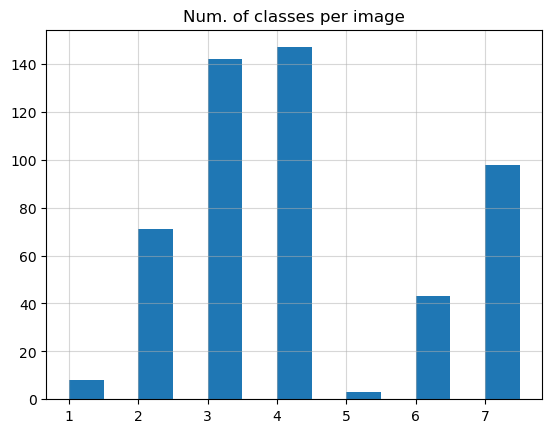

In [6]:
plt.hist(n_classes_per_img, bins=np.arange(1., 8., 0.5))
plt.grid(alpha=0.5)
plt.title('Num. of classes per image');

### Class distribution

In [7]:
labels = (
    'SKY',
    'GROUND',
    'WALL',
    'OBJ',
    'BOT',
    'BODY',
    'CARGO')

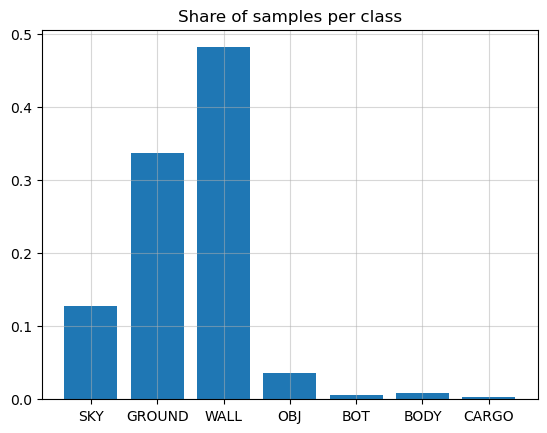

In [8]:
class_distr = np.zeros(7)

for i in range(7):
    class_distr[i] += (seg == i).sum()

plt.bar(np.arange(1, 8), class_distr / class_distr.sum())
plt.grid(alpha=0.5)
plt.xticks(np.arange(1, 8), labels)
plt.title('Share of samples per class');

## Weights

### Imbalance correction

In [9]:
weights_corr = (
    np.where(seg == 0., 0.01, 0.) +
    np.where(seg == 1., 0.01, 0.) +
    np.where(seg == 2., 0.033, 0.) +
    np.where(seg == 3., 0.67, 0.) +
    np.where(seg == 4., 1., 0.) +
    np.where(seg == 5., 1., 0.) +
    np.where(seg == 6., 2., 0.))

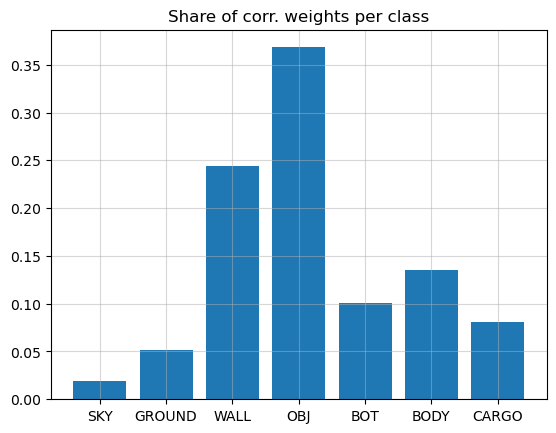

In [10]:
weight_distr = np.zeros(7)

for i in range(7):
    weight_distr[i] += np.where(seg == i, weights_corr, 0.).sum()

plt.bar(np.arange(1, 8), weight_distr / weight_distr.sum())
plt.grid(alpha=0.5)
plt.xticks(np.arange(1, 8), labels)
plt.title('Share of corr. weights per class');

### Colour emphasis

In [11]:
rgb = dtr[:, :3]
rgb_max = np.amax(rgb, axis=1)
saturation = (rgb_max - np.amin(rgb, axis=1)) / np.maximum(rgb_max, 1e-6)

In [12]:
saturation.min()

0.0

In [13]:
weights_sat = np.clip(saturation, 1e-4, 1.)

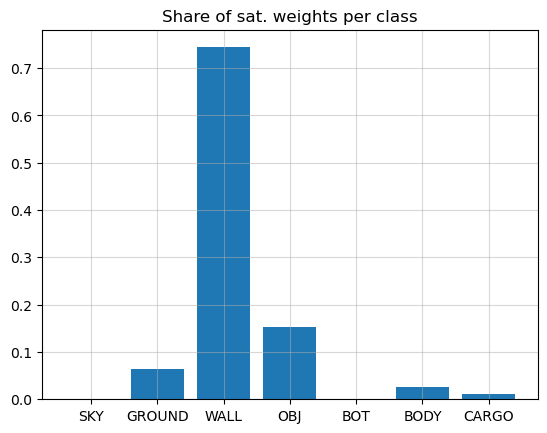

In [14]:
weight_distr = np.zeros(7)

for i in range(7):
    weight_distr[i] += np.where(seg == i, weights_sat, 0.).sum()

plt.bar(np.arange(1, 8), weight_distr / weight_distr.sum())
plt.grid(alpha=0.5)
plt.xticks(np.arange(1, 8), labels)
plt.title('Share of sat. weights per class');

### Combined weights

In [15]:
weights = weights_corr + weights_sat

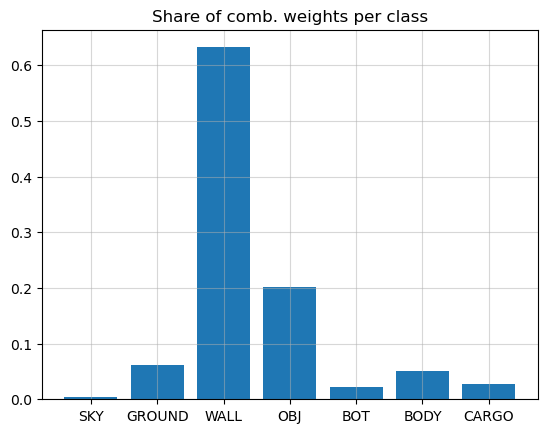

In [16]:
weight_distr = np.zeros(7)

for i in range(7):
    weight_distr[i] += np.where(seg == i, weights, 0.).sum()

plt.bar(np.arange(1, 8), weight_distr / weight_distr.sum())
plt.grid(alpha=0.5)
plt.xticks(np.arange(1, 8), labels)
plt.title('Share of comb. weights per class');

## Saving

In [17]:
dtr = np.concatenate((dtr, weights_corr[:, None]), axis=1)
dtr = torch.from_numpy(dtr.astype(np.float32))

In [18]:
torch.save(dtr, '../data/dataset.pt')